In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('IBM_HR.csv')
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
print(df.shape)

(1470, 31)


In [3]:
# Industry standard estimates
RECRUITMENT_COST = 15000        # Cost to recruit one employee
TRAINING_COST = 10000           # Cost to train one employee
PRODUCTIVITY_LOSS_MONTHS = 3    # Months of lost productivity
AVG_MONTHLY_SALARY = df['MonthlyIncome'].mean()

print(f"Average Monthly Salary: ₹{round(AVG_MONTHLY_SALARY, 2)}")
print(f"Recruitment Cost: ₹{RECRUITMENT_COST}")
print(f"Training Cost: ₹{TRAINING_COST}")

Average Monthly Salary: ₹6502.93
Recruitment Cost: ₹15000
Training Cost: ₹10000


In [4]:
productivity_loss = PRODUCTIVITY_LOSS_MONTHS * AVG_MONTHLY_SALARY
total_cost_per_employee = RECRUITMENT_COST + TRAINING_COST + productivity_loss

print(f"Productivity Loss per employee: ₹{round(productivity_loss, 2)}")
print(f"Total Cost per Attrition: ₹{round(total_cost_per_employee, 2)}")

Productivity Loss per employee: ₹19508.79
Total Cost per Attrition: ₹44508.79


In [5]:
dept_attrition = df[df['Attrition'] == 'Yes'].groupby('Department').size().reset_index(name='Attrition_Count')
dept_attrition['Total_Cost'] = dept_attrition['Attrition_Count'] * total_cost_per_employee

print(dept_attrition)

               Department  Attrition_Count    Total_Cost
0         Human Resources               12  5.341055e+05
1  Research & Development              133  5.919670e+06
2                   Sales               92  4.094809e+06


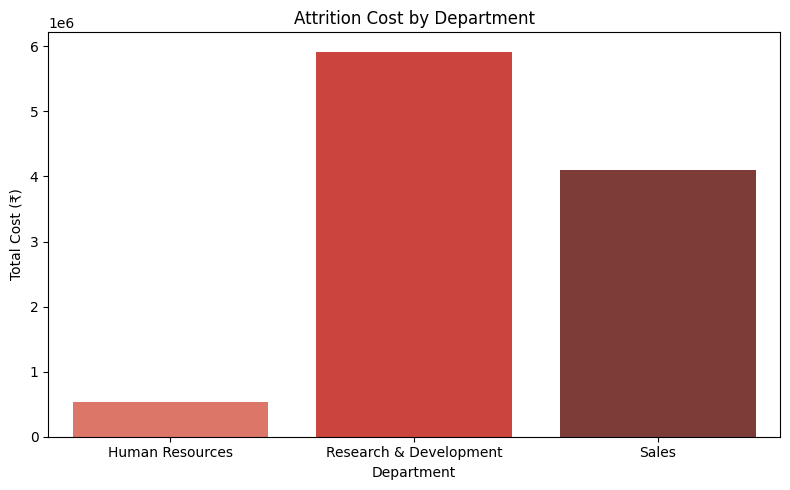

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x='Department', y='Total_Cost', hue='Department', 
            data=dept_attrition, palette='Reds_d', legend=False)
plt.title('Attrition Cost by Department')
plt.ylabel('Total Cost (₹)')
plt.xlabel('Department')
plt.tight_layout()
plt.show()

In [7]:
total_attrition = df[df['Attrition'] == 'Yes'].shape[0]
overall_cost = total_attrition * total_cost_per_employee

print(f"Total Employees who left: {total_attrition}")
print(f"Total Attrition Cost to Company: ₹{round(overall_cost, 2)}")

Total Employees who left: 237
Total Attrition Cost to Company: ₹10548584.15
